In [1]:
%matplotlib inline
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve
from src.metrics import delong_test, wilcoxon_paired, bonferroni
RES = Path("../results")
PASS = "tuned"   # change to "tuned" and re-execute the cells for second pass
df = pd.read_csv(RES / f"per_fold_{PASS}.csv")
preds = pd.read_parquet(RES / f"predictions_{PASS}.parquet")
models = list(df["model"].unique())
CHAMPION = "woe_logit"

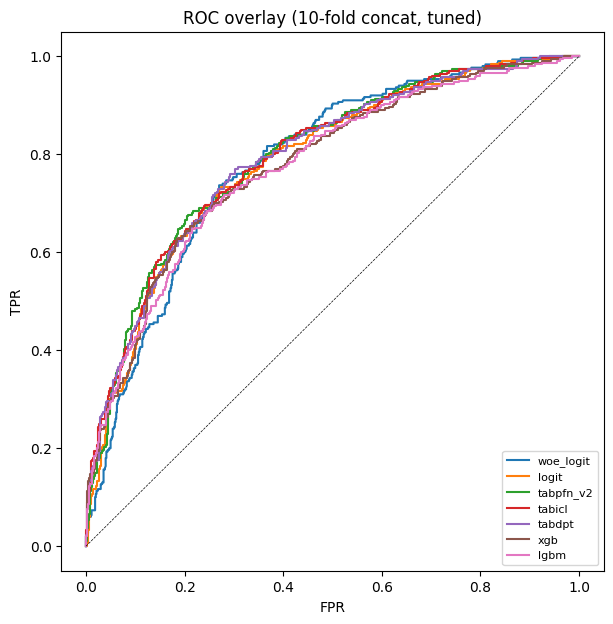

In [2]:
fig, ax = plt.subplots(figsize=(7, 7))
for m in models:
    sub = preds[preds.model == m]
    fpr, tpr, _ = roc_curve(sub["y"], sub["proba"])
    ax.plot(fpr, tpr, label=m, lw=1.5)
ax.plot([0, 1], [0, 1], "k--", lw=0.5)
ax.set(xlabel="FPR", ylabel="TPR", title=f"ROC overlay (10-fold concat, {PASS})")
ax.legend(loc="lower right", fontsize=8)
fig.savefig(RES / "figures" / f"roc_overlay_{PASS}.png", dpi=150, bbox_inches="tight")
plt.show()

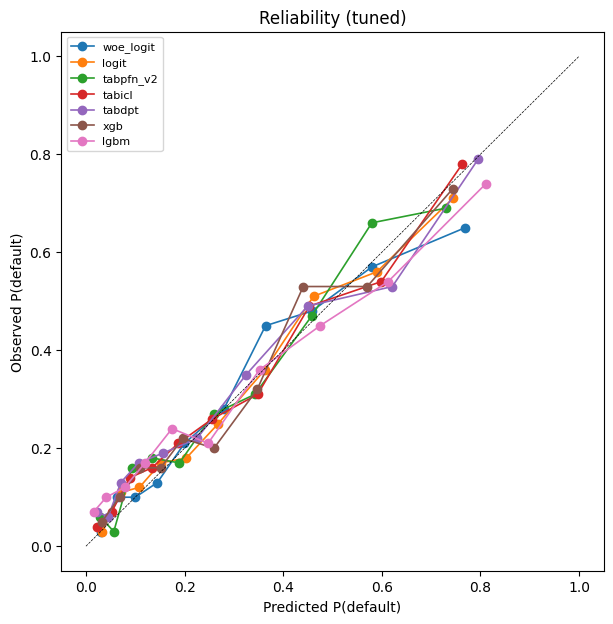

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
for m in models:
    sub = preds[preds.model == m]
    prob_true, prob_pred = calibration_curve(sub["y"], sub["proba"], n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", label=m, lw=1.2)
ax.plot([0, 1], [0, 1], "k--", lw=0.5)
ax.set(xlabel="Predicted P(default)", ylabel="Observed P(default)", title=f"Reliability ({PASS})")
ax.legend(fontsize=8)
fig.savefig(RES / "figures" / f"reliability_{PASS}.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/8f/h0_gz4hs3zxd1k2hs3ly55n80000gn/T/ipykernel_73356/1893160310.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=models, vert=True)


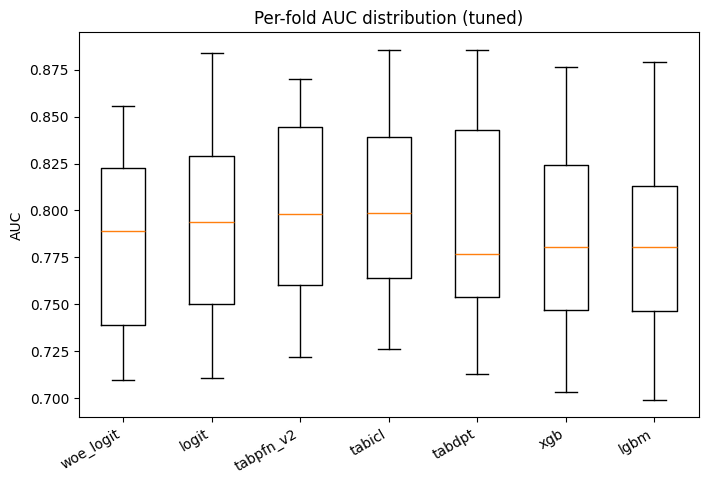

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
data = [df[df.model == m]["auc"].values for m in models]
ax.boxplot(data, labels=models, vert=True)
ax.set(ylabel="AUC", title=f"Per-fold AUC distribution ({PASS})")
plt.xticks(rotation=30, ha="right")
fig.savefig(RES / "figures" / f"auc_boxplot_{PASS}.png", dpi=150, bbox_inches="tight")
plt.show()

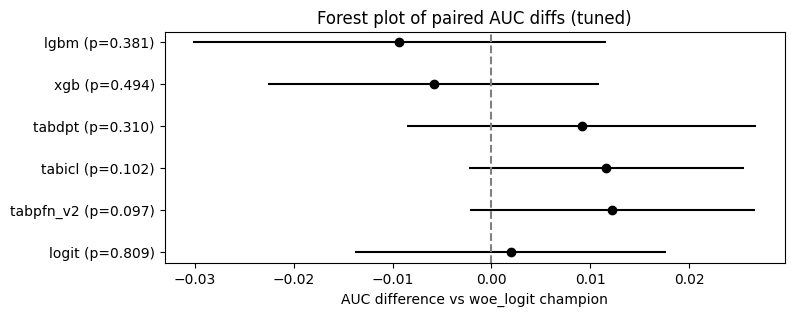

,model,diff,lo,hi,p
0,logit,0.001938,-0.013763,0.017639,0.808825
1,tabpfn_v2,0.012219,-0.002198,0.026636,0.096673
2,tabicl,0.011610,-0.002317,0.025536,0.102285
3,tabdpt,0.009138,-0.008505,0.026781,0.310024
4,xgb,-0.005838,-0.022549,0.010873,0.493510
5,lgbm,-0.009324,-0.030186,0.011539,0.381050


In [5]:
ch = preds[preds.model == CHAMPION].sort_values(["fold_idx", "test_idx"])
y_all = ch["y"].values
p_ch = ch["proba"].values

rows = []
for m in models:
    if m == CHAMPION: continue
    sub = preds[preds.model == m].sort_values(["fold_idx", "test_idx"])
    p_m = sub["proba"].values
    z, p = delong_test(y_all, p_m, p_ch)
    diff = roc_auc_score(y_all, p_m) - roc_auc_score(y_all, p_ch)
    se = abs(diff / z) if z != 0 else 0.05
    rows.append((m, diff, diff - 1.96 * se, diff + 1.96 * se, p))
fdf = pd.DataFrame(rows, columns=["model", "diff", "lo", "hi", "p"])

fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(fdf))))
ax.errorbar(fdf["diff"], range(len(fdf)),
            xerr=[fdf["diff"] - fdf["lo"], fdf["hi"] - fdf["diff"]],
            fmt="o", color="black")
ax.axvline(0, color="grey", ls="--")
ax.set_yticks(range(len(fdf)))
ax.set_yticklabels([f"{r.model} (p={r.p:.3f})" for _, r in fdf.iterrows()])
ax.set_xlabel("AUC difference vs woe_logit champion")
ax.set_title(f"Forest plot of paired AUC diffs ({PASS})")
fig.savefig(RES / "figures" / f"forest_{PASS}.png", dpi=150, bbox_inches="tight")
plt.show()
fdf

In [6]:
rt = df.groupby("model")["runtime_s"].agg(["mean", "sum"]).round(2)
rt.columns = ["mean_s_per_fold", "total_s"]
rt.sort_values("total_s", ascending=False)

,mean_s_per_fold,total_s
model,,
tabpfn_v2,2.54,25.43
tabicl,1.10,11.02
tabdpt,0.70,7.01
woe_logit,0.07,0.68
xgb,0.05,0.50
lgbm,0.04,0.44
logit,0.01,0.08


In [7]:
from IPython.display import Markdown, display
display(Markdown((RES / f"summary_{PASS}.md").read_text()))

> **Scope of claim (narrow):** This benchmark addresses *discriminatory power only*. It does NOT support the broader claim that "TFMs are better PD models" — that would require calibration quality, rating-grade homogeneity/heterogeneity, PSI stability, and out-of-time validation, all of which the `pd-autopilot` pipeline provides for the incumbent but are out of scope here. Brier and log-loss are reported as **probability-quality (secondary)** metrics — they combine discrimination with calibration, so a challenger that ties on AUC but loses on Brier is producing well-ranked but mis-scaled probabilities, which is a calibration story outside this benchmark's primary scope.

## Headline (10-fold CV)

| Model | AUC | GINI | KS | BRIER (sec.) | LOGLOSS (sec.) | DeLong p | DeLong (bonf) | Wilcoxon p | Wilcoxon (bonf) |
|---|---|---|---|---|---|---|---|---|---|
| woe_logit | 0.7840 ± 0.0509 | 0.5681 ± 0.1018 | 0.5205 ± 0.1000 | 0.1684 ± 0.0207 | 0.5045 ± 0.0515 | reference | reference | reference | reference |
| logit | 0.7875 ± 0.0569 | 0.5750 ± 0.1138 | 0.5171 ± 0.1049 | 0.1644 ± 0.0206 | 0.4992 ± 0.0531 | 0.809 | 1.000 | 0.625 | 1.000 |
| tabpfn_v2 | 0.8000 ± 0.0513 | 0.5999 ± 0.1026 | 0.5319 ± 0.0875 | 0.1600 ± 0.0187 | 0.4888 ± 0.0508 | 0.097 | 0.580 | 0.105 | 0.633 |
| tabicl | 0.7995 ± 0.0527 | 0.5990 ± 0.1054 | 0.5181 ± 0.1129 | 0.1595 ± 0.0202 | 0.4875 ± 0.0559 | 0.102 | 0.614 | 0.090 | 0.539 |
| tabdpt | 0.7942 ± 0.0613 | 0.5885 ± 0.1226 | 0.5152 ± 0.1070 | 0.1617 ± 0.0219 | 0.4952 ± 0.0656 | 0.310 | 1.000 | 0.232 | 1.000 |
| xgb | 0.7865 ± 0.0557 | 0.5730 ± 0.1113 | 0.5138 ± 0.0919 | 0.1652 ± 0.0198 | 0.5033 ± 0.0521 | 0.494 | 1.000 | 0.695 | 1.000 |
| lgbm | 0.7828 ± 0.0531 | 0.5656 ± 0.1062 | 0.4957 ± 0.0770 | 0.1676 ± 0.0182 | 0.5178 ± 0.0624 | 0.381 | 1.000 | 1.000 | 1.000 |

*Primary discrimination metrics: AUC, Gini, KS. Probability-quality (secondary) metrics: Brier, log-loss — sensitive to calibration, not part of the primary claim (see disclaimer above).*

## Context (not directly comparable — different preprocessing path / fold seed)
- Report dev AUC (in-sample, loans_clean): 0.8109
- Report 10-fold CV AUC (loans_clean): 0.8065
- Report bootstrap AUC: 0.8026
